<a href="https://colab.research.google.com/github/04suman/sumanamit/blob/main/KOA_VGG_19_Binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import PIL
import cv2
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os


In [ ]:
good=os.listdir("/content/drive/MyDrive/mydata/train/0/")

In [ ]:
b4=os.listdir("/content/drive/MyDrive/mydata/train/3/")


In [ ]:
bad=b4[:1000]

In [ ]:
x1=[]
y1=[]
for i in good[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/0/"+i))
    x1.append(x)
    y1.append(1)


In [ ]:
print(x1[1])

[[[135 135 135]
  [134 134 134]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [135 135 135]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [136 136 136]
  [136 136 136]
  ...
  [179 179 179]
  [178 178 178]
  [177 177 177]]

 ...

 [[ 67  67  67]
  [ 68  68  68]
  [ 69  69  69]
  ...
  [170 170 170]
  [168 168 168]
  [164 164 164]]

 [[ 66  66  66]
  [ 67  67  67]
  [ 70  70  70]
  ...
  [168 168 168]
  [166 166 166]
  [164 164 164]]

 [[ 67  67  67]
  [ 68  68  68]
  [ 71  71  71]
  ...
  [168 168 168]
  [166 166 166]
  [163 163 163]]]


In [ ]:
x2=[]
y2=[]
for i in bad[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/3/"+i))
    x2.append(x)
    y2.append(0)

xdata=x1+x2
ydata=y1+y2

In [ ]:
xdata=np.array(xdata)
ydata=np.array(ydata)
xdata=xdata/255
ydata

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg19/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model19 = tf.keras.models.Sequential()
model19.add(base_model)
model19.add(tf.keras.layers.Flatten())
model19.add(tf.keras.layers.Dropout(0.5))
model19.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model19.layers[0].trainable = False
model19.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model19.summary()

80134624/80134624 [==============================] - 5s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dropout (Dropout)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 1)                 25089     
                                                                 
Total params: 20049473 (76.48 MB)
Trainable params: 25089 (98.00 KB)
Non-trainable params: 20024384 (76.39 MB)
_________________________________________________________________


In [ ]:
# prompt: vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5' base_model = tf.keras.applications.VGG16(     weights=vgg16_weight_path,     include_top=False,     input_shape=IMG_SIZE + (3,) )  model = tf.keras.models.Sequential() model.add(base_model) model.add(tf.keras.layers.Flatten()) model.add(tf.keras.layers.Dropout(0.5)) model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  model.layers[0].trainable = False  model.compile(     loss='binary_crossentropy',     optimizer=tf.keras.optimizers.Adam(),     metrics=['accuracy'] )  model  .summary()
'''IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model = tf.keras.models.Sequential()
model.add(base_model)
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.layers[0].trainable = False
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model.summary()'''


In [ ]:
IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg19/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model19 = tf.keras.models.Sequential()
model19.add(base_model)
model19.add(tf.keras.layers.Flatten())
model19.add(tf.keras.layers.Dropout(0.5))
model19.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model19.layers[0].trainable = False
model19.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model19.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,049,473 (76.48 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(xdata,ydata,test_size=0.2,random_state=43)

In [ ]:
history19=model19.fit(xtrain,ytrain,epochs=60)

Epoch 1/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 491ms/step - accuracy: 0.5058 - loss: 0.7914
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.6391 - loss: 0.6336
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.6965 - loss: 0.5604
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.7269 - loss: 0.5253
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.7604 - loss: 0.4844
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.7610 - loss: 0.4797
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.7909 - loss: 0.4668
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.7906 - loss: 0.4329
Epoch 9/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - accuracy: 0.7720 - loss: 0.4658
Epoch 10/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - accuracy: 0.7742 - loss: 0.4393
Epoch 11/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - accuracy: 0.7977 - loss: 0.3940
Epoch 12/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/st

In [ ]:
model19.evaluate(xtest,ytest)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.8107 - loss: 0.3665


[0.3606967628002167, 0.8301281929016113]

In [ ]:
model19.evaluate(xtest,ytest)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.8107 - loss: 0.3665


[0.3606967628002167, 0.8301281929016113]

In [ ]:
'''history=model.fit(xtrain,ytrain,epochs=100)

In [ ]:
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score

In [ ]:
ypred=model19.predict(xtest)
yp=[1 if x>0.5 else 0 for x in ypred]

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(ytest,yp)*100

83.01282051282051

In [ ]:
yp[:5]

[0, 1, 0, 1, 0]

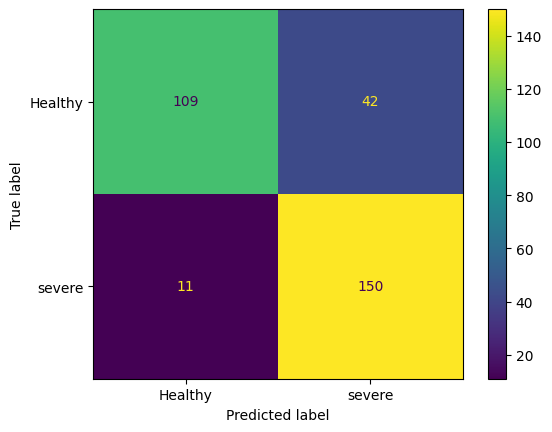

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
cm = confusion_matrix(ytest, yp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Healthy','severe'])

disp.plot()
plt.show()

In [ ]:
print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)*100)
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)*100)

F1 score: 84.98583569405099
Recall: 93.16770186335404
Precision: 78.125

 clasification report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80       151
           1       0.78      0.93      0.85       161

    accuracy                           0.83       312
   macro avg       0.84      0.83      0.83       312
weighted avg       0.84      0.83      0.83       312
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       151
           1       0.78      0.93      0.85       161

    accuracy                           0.83       312
   macro avg       0.84      0.83      0.83       312
weighted avg       0.84      0.83      0.83       312
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       151
           1       0.78      0.93      0.85       161

    accuracy                           0.83       312
   macro avg       0.84      0.83

In [ ]:
(11700+15300)/(3400+800+11700+15300)

0.8653846153846154

In [ ]:
loss_list=history19.history['loss']
acc_list=history19.history['accuracy']

epoch_list=[i for i in range(60)]

In [ ]:
import matplotlib.pyplot as plt

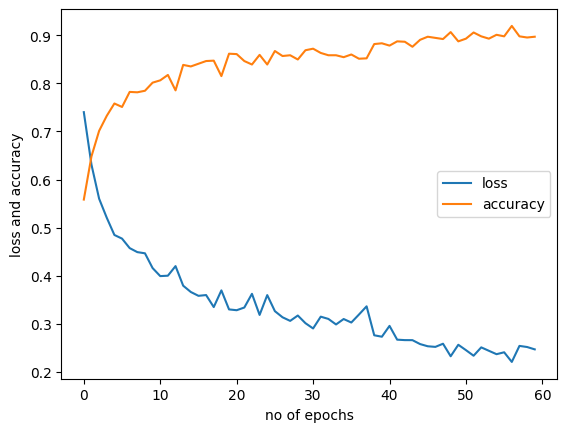

In [ ]:
plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(epoch_list,loss_list)
plt.plot(epoch_list,acc_list)
plt.legend(['loss','accuracy'],loc='center right')

plt.show()


In [ ]:
history19=model19.fit(xtrain,ytrain,epochs=10)

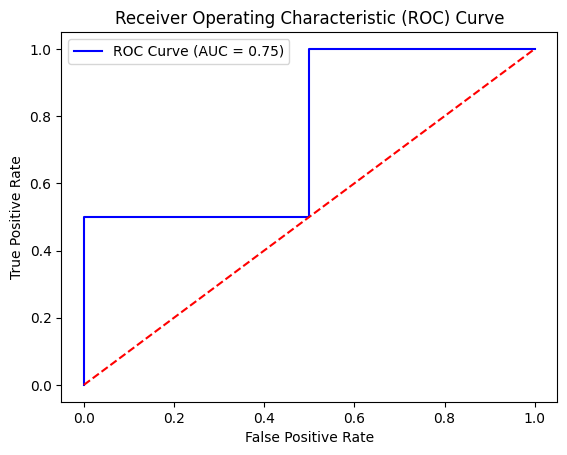

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Example data (true labels and model probabilities)
y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # predicted probabilities from model

# Step 1: Calculate FPR, TPR
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Step 2: Calculate AUC
auc_score = roc_auc_score(y_true, y_scores)

# Step 3: Plot the ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line (random model)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step


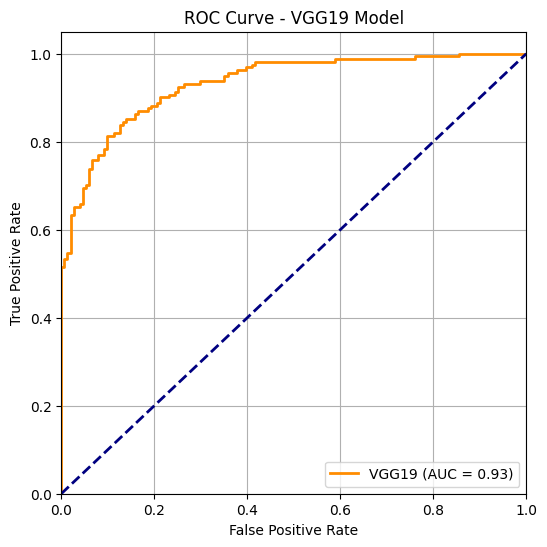

In [ ]:
# Example for binary classification with VGG19
# model is your trained VGG19 model
# X_test is your test dataset

# Get prediction probabilities (for the positive class)
y_pred_prob = model19.predict(xtest)  # shape = (n_samples, 1) or (n_samples, 2)
# The output of model19.predict is already (n_samples, 1), so no need to select index 1

# Compute ROC values
fpr, tpr, thresholds = roc_curve(ytest, y_pred_prob)
roc_auc = roc_auc_score(ytest, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'VGG19 (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - VGG19 Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()